In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


pa_gs = pd.read_csv('data/pa_data.csv')

def remove_nulls_simple(data_set, columns):
    #takes the name of a data set and the selected columns and returns a cleaned data set, dropping only rows
    #where the inputted columns have null values

    data_set_cleaned = data_set.dropna(subset=columns, ignore_index=True)
    return data_set_cleaned[columns]

In [102]:
test_cols = ['year','growing_season_length','dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
pa_gs_test = remove_nulls_simple(pa_gs, test_cols)
pa_gs_test_df = pd.DataFrame(pa_gs_test[pa_gs_test['year'] > 1900].groupby('year').agg(['mean']))
pa_gs_test_df.columns = ['_'.join(col).strip() for col in pa_gs_test_df.columns.values]
pa_gs_test_df = pa_gs_test_df.reset_index()
pa_gs_test_df.columns = test_cols
pa_gs_test_df.describe()

,year,growing_season_length,dtr_annual,dtr_spring,dtr_summer,tmax_annual,prcp_annual_mm,prcp_growing_season_mm,prcp_spring_mm,latitude,...,cloud_cover_northeast_us,evaporation_northeast_us,dewpoint_2m_pennsylvania,soil_moisture_pennsylvania,cloud_cover_pennsylvania,evaporation_pennsylvania,dewpoint_station,soil_moisture_station,cloud_cover_station,evaporation_station
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,...,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,1986.500000,162.535073,11.678046,12.603219,12.714134,15.903565,1079.610908,537.503941,277.873376,40.734602,...,0.633270,2.414340,4.513107,0.360891,0.618537,1.927414,4.600688,0.368223,0.618552,1.937940
std,21.505813,11.867497,0.479828,0.721948,0.848251,0.695834,140.821549,113.534440,53.567929,0.035207,...,0.019255,0.101936,0.711233,0.012844,0.027962,0.079703,0.725674,0.012881,0.028765,0.084902
min,1950.000000,133.768519,10.214626,11.135830,10.959267,14.707016,794.149074,303.079630,191.766250,40.638150,...,0.584080,2.193307,2.760498,0.332146,0.557712,1.721428,2.854046,0.338687,0.556009,1.735381
25%,1968.250000,154.884015,11.372430,12.161402,12.169274,15.481432,1007.186303,472.250488,241.227546,40.717849,...,0.620535,2.353177,3.995838,0.352546,0.600970,1.876392,4.135982,0.359630,0.598135,1.891380
50%,1986.500000,162.298697,11.662732,12.676925,12.687023,15.683835,1068.806250,526.814715,271.136953,40.738250,...,0.633485,2.412223,4.532840,0.359720,0.619276,1.936405,4.634740,0.367373,0.618286,1.947777
75%,2004.750000,170.395055,11.909956,13.038749,13.201203,16.335821,1143.614654,583.964170,312.820774,40.752918,...,0.647851,2.485275,5.010621,0.368583,0.636840,1.979842,5.155051,0.377446,0.640477,1.992976
max,2023.000000,188.861386,13.023754,14.417108,15.237700,17.399714,1556.210465,892.894059,463.150495,40.817630,...,0.678853,2.611353,6.248860,0.388815,0.701359,2.071475,6.370881,0.394630,0.699941,2.090978


In [125]:
X = pa_gs_test_df[['dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm','oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
y = pa_gs_test_df['growing_season_length']

def multiple_regression_v_2(data_subset, input_variables, predicted_variable):
    #performs a standardized multiple linear regression to create a model of y based on the variables within X.
    # Required Libraries: r2score, mean_absolute_error, and mean_squared_error from sklearn.metrics, 
    # train_test_split from sklearn.model_selection, linear_model from sklearn, and StandardScaler from sklearn.preprocessing


    #counts total data points included in regression
    tot_data_points = len(data_subset)
    
    #splits data into training and testing groups
    X_train, X_test, y_train, y_test = train_test_split(input_variables, predicted_variable, test_size = 0.2, random_state = 0)

    #converts y_train, y_test, and y_cleaned into series
    #y_train= y_train.squeeze()
    #y_test= y_test.squeeze()
    #y_cleaned = y_cleaned.squeeze()
    
    #scales input data to standardize to mean of 0 and standard deviation of 1
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.fit_transform(X_test)
    
    #creates multiple regression model based on training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_scaled, y_train)

    #calculates mean absolute error, mean squared error, and r squared score based on the predicted y
    y_predicted = regr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_predicted)
    mse = mean_squared_error(y_test, y_predicted)
    rmse = np.sqrt(mse)
    r_2_score = r2_score(y_test, y_predicted)
    n = len(predicted_variable)
    p = input_variables.shape[1]
    adj_r2_score = 1 - ((1 - r_2_score) * (n - 1) / (n - p - 1))
    y_std = predicted_variable.std().round(5)
    coefficients = pd.DataFrame(zip(input_variables.columns, input_variables.std().round(5), regr.coef_.round(5)))

    coefficients.columns = ['variable', 'var standard dev', 'coefficient']
    
    results = [f'MAE = {mae}', f'MSE = {mse}', f'RMSE = {rmse}', f'R Squared = {r_2_score}', 
               f'Adj. R Squared = {adj_r2_score}', f'Total Data Points = {tot_data_points}',
               f'(Reference) predicted variable standard deviation = {y_std}', coefficients]
    
    return display(results)

In [126]:
multiple_regression_v_2(pa_gs_test_df, X, y)

['MAE = 11.815026386154278',
 'MSE = 213.73961856289046',
 'RMSE = 14.619836475244531',
 'R Squared = -0.5463132011898162',
 'Adj. R Squared = -2.420632232935048',
 'Total Data Points = 74',
 '(Reference) predicted variable standard deviation = 11.8675',
                       variable  var standard dev  coefficient
 0                   dtr_spring           0.72195      0.38689
 1                   dtr_summer           0.84825      2.46003
 2                  tmax_annual           0.69583     -0.72534
 3               prcp_annual_mm         140.82155     -1.15336
 4       prcp_growing_season_mm         113.53444     13.19766
 5               prcp_spring_mm          53.56793      0.21791
 6                   oni_annual           0.62528     -0.45022
 7                   nao_annual           0.37356      0.38052
 8                      nao_djf           0.82785      1.26867
 9                   pna_annual           0.35285     -0.04277
 10                  amo_annual           0.19492   

This code has definitely got something wrong with it -- the random state has a huge effect on the R2 value, and the R2 value itself is negative which doesn't make any sense to me. Model is also not spectacularly accurate according to R2 value, but the MAE and RMSE are not hugely worse than the MAE and RMSE of the model using all the data points instead of the yearly means

# Autocorrelation Modeling

In [3]:
from statsmodels.graphics.tsaplots import plot_acf

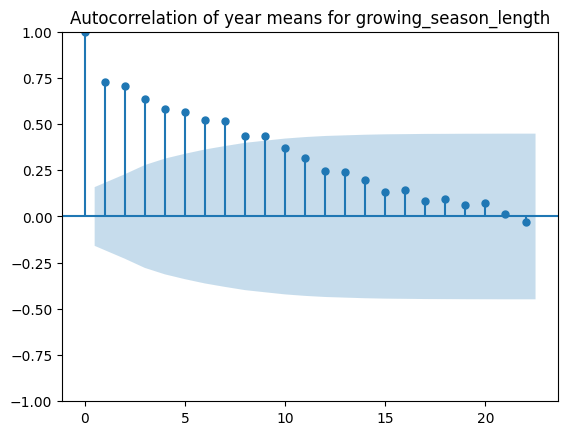

In [174]:
def temp_ac_plot(data_set, data_division, variable):
    df = data_set
    grouped_data = df.groupby(data_division)[variable].agg('mean')
    plot_acf(grouped_data)
    plt.title(f'Autocorrelation of {data_division} means for {variable}')
    plt.show()

#pa_gs_date_limited = pa_gs[pa_gs['year'].between(1905, 1965)]
#pa_gs_date_limited = pa_gs[pa_gs['year'] > 1965]
temp_ac_plot(pa_gs, 'year', 'growing_season_length')

* Autocorrelation is not statistically significant beyond 9 years at 95%
* In those 9 years the autocorrelation is positive --> a long growing season one year is associated with longer than average growing season in the following 8 years

This all assumes the plotting is correct, but I believe based on the simplicity of the code and having checked the input to be what I want it to be, I have a certain degree of confidence that it is.

In [49]:
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

coastal_pa_gs_gsl = coastal_pa_stations.groupby('year')['growing_season_length'].agg('mean')
lakeside_pa_gs_gsl = lakeside_pa_stations.groupby('year')['growing_season_length'].agg('mean')
inland_pa_gs_gsl = inland_pa_stations.groupby('year')['growing_season_length'].agg('mean')

Figure(640x480)


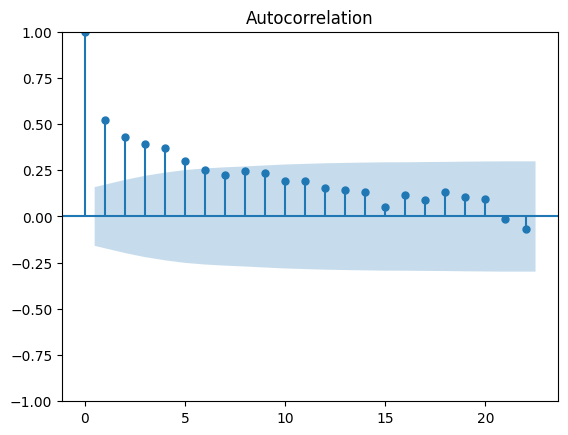

In [50]:
acf_plt_coastal = plot_acf(coastal_pa_gs_gsl)
print(acf_plt_coastal)

* the mean of coastal stations has statistically significant temporal autocorrelation for 5 years, as compared to the 9 of the  mean of all stations. The obvious reason for this would be that this is a smaller dataset so individual variations in data from singular stations have a greater impact.
* Autocorrelation in these 5 years is once again positive, so long growing season one year would indicate longer growing seasons for the next 5 in areas within 150 km of the coast.

Figure(640x480)


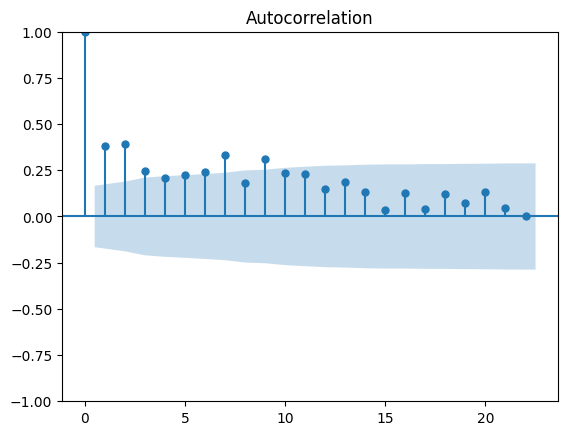

In [51]:
acf_plt_inland = plot_acf(inland_pa_gs_gsl)
print(acf_plt_inland)

* Inland subset is the largest of the subsets -- includes all stations neither within 150 km of the lake or coast. While it is still smaller than the whole dataset, it is not as significantly smaller as the lakeside or coastal subset.
* Seemingly much less temporal autocorrelation in growing season length for inland stations. Statistical significance for inland station autocorrelation extends only for 3 years before dipping below the 95% threshold.
* Interestingly enough, it does regain statistical significance briefly at 7 and 9 years, but I suspect this may be as a result of outliers
* once again, positively autocorrelated, so long growing season one year inland would indicate longer growing seasons for the next two years.

Figure(640x480)


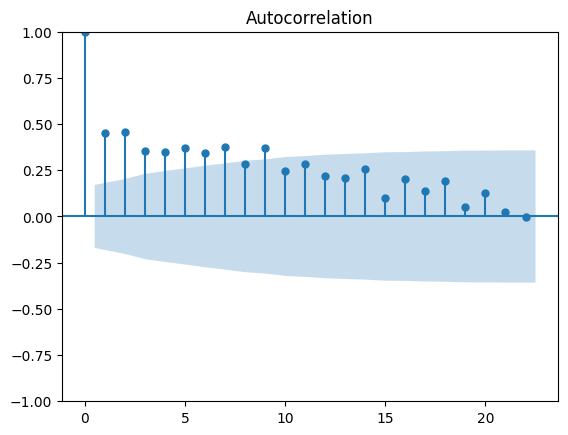

In [52]:
acf_plt_lakeside = plot_acf(lakeside_pa_gs_gsl)
print(acf_plt_lakeside)

* The lakeside subset is exceptionally small compared to the overall dataset or the inland subset, so there is not much stock to take in this autocorrelation result
* Statistical significance at 95% extends for 7 years, and is positively correlated

Figure(640x480)


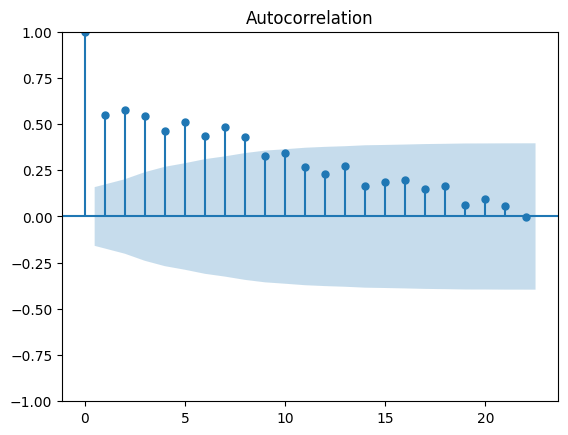

In [53]:
pa_gs_lsf = pa_gs.groupby('year')['last_spring_frost_doy'].agg('mean')
acf_plt_2 = plot_acf(pa_gs_lsf)
print(acf_plt_2)

* across the whole state, last spring frost date is postively autocorrelated with statistical significance of 95% for 8 years.
* Indicates a late spring frost would make you expect a relatively late spring frost for the next 8 years in Pennsylvania

Figure(640x480)


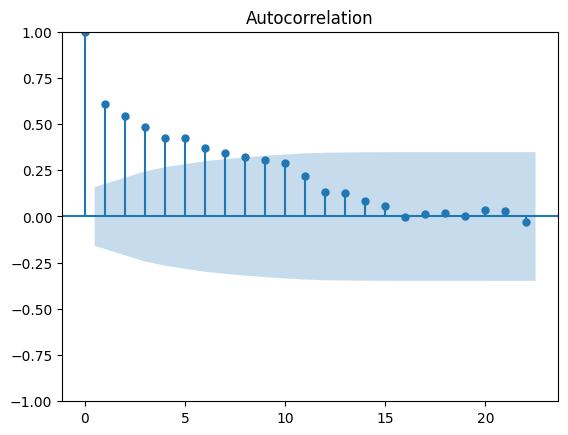

In [54]:
pa_gs_fff = pa_gs.groupby('year')['first_fall_frost_doy'].agg('mean')
acf_plt_3 = plot_acf(pa_gs_fff)
print(acf_plt_3)

* across the whole state, first fall frost is positively autocorrelated with statistical significance of 95% for 7 (or potentially 8, it seems to be right on the border) years
* indicates a late fall frost one year would make you expect a relatively late fall frost for the next 8 years in pennsylvania

In [100]:
pa_gs_e = pa_gs[pa_gs['dist_atlantic_km'] < pa_gs['dist_greatlakes_km']]
pa_gs_w = pa_gs[pa_gs['dist_atlantic_km'] > pa_gs['dist_greatlakes_km']]

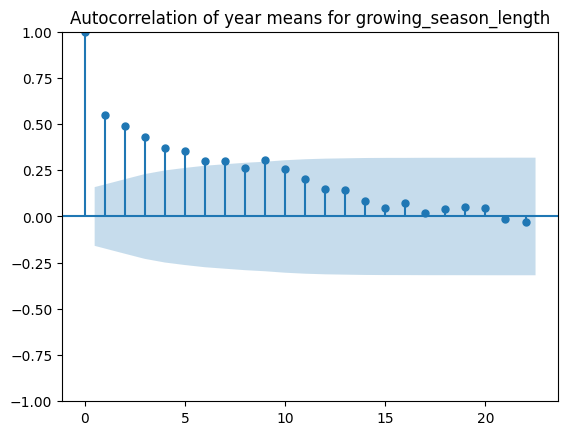

In [102]:
temp_ac_plot(pa_gs_e, 'year', 'growing_season_length')

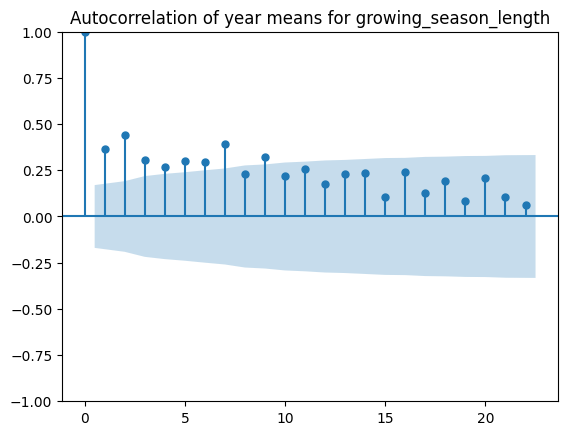

In [103]:
temp_ac_plot(pa_gs_w, 'year', 'growing_season_length')